In [92]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.io.geojson_loader import GeoJsonLoader
from src.projection.transformer import UTMTransformer

FIGURE_DIR = Path("../reports/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT = Path.cwd().parent.resolve()
RAW_PATH = (PROJECT_ROOT / "data" / "raw" / "iran_city.json").resolve()

print(RAW_PATH)
print(RAW_PATH.exists())

D:\Spatial_Intelligence_Engine\data\raw\iran_city.json
True


In [93]:
import matplotlib.pyplot as plt
import pandas as pd
import json

In [94]:
loader = GeoJsonLoader(RAW_PATH)

In [95]:
gorgan = loader.load_city("گرگان")

print(gorgan)
print(len(gorgan))

Polygon(vertices=326)
326


In [96]:
def simplify_city_boundary(city_name, tolerance=100):
    polygon = loader.load_city(city_name)
    transformer = UTMTransformer.from_point(polygon.centroid())
    polygon_meter = polygon.transform(transformer)
    simplified = polygon_meter.simplify(tolerance)
    
    return polygon, polygon_meter, simplified

In [97]:
gorgan, gorgan_meter, gorgan_simple = simplify_city_boundary("گرگان", 100)

print("Original:", len(gorgan))
print("Simplified:", len(gorgan_simple))

Original: 326
Simplified: 90


In [98]:
def plot_polygon_simplification(original, simplified, title):

    original_x = [p.x for p in original.vertices]
    original_y = [p.y for p in original.vertices]

    simple_x = [p.x for p in simplified.vertices]
    simple_y = [p.y for p in simplified.vertices]


    plt.figure(figsize=(10, 10))


    # original boundary - very light
    plt.plot(
        original_x,
        original_y,
        linewidth=0.5,
        alpha=0.3,
        label="Original boundary"
    )


    # original points
    plt.scatter(
        original_x,
        original_y,
        s=12,
        marker="o",
        facecolors="none",
        edgecolors="orange",
        alpha=0.7,
        label=f"Original vertices ({len(original.vertices)})"
    )


    # simplified boundary - also light
    plt.plot(
        simple_x,
        simple_y,
        linewidth=0.8,
        alpha=0.5,
        label="Simplified boundary"
    )


    # simplified points
    plt.scatter(
        simple_x,
        simple_y,
        s=25,
        marker="s",
        alpha=0.9,
        label=f"Simplified vertices ({len(simplified.vertices)})"
    )


    plt.title(title)
    plt.axis("equal")
    plt.legend()
    plt.grid(True)

    plt.show()

In [99]:
all_cities = loader.cities()

print(type(all_cities))
print(len(all_cities))
print(all_cities[:20])

<class 'list'>
429
['آبادان', 'آباده', 'آبدانان', 'آبیک', 'آذرشهر', 'آرادان', 'آران وبیدگل', 'آزادشهر', 'آستارا', 'آستانه اشرفیه', 'آشتیان', 'آغاجاری', 'آق قلا', 'آمل', 'آوج', 'ابرکوه', 'ابهر', 'ابوموسی', 'اراک', 'اردبیل']


In [100]:
processed_cities = {}
failed_cities = []
for city in all_cities:
    try:
        original, original_meter, simplified = simplify_city_boundary(city, 100)
        processed_cities[city] = simplified
        print(city)
    except Exception as e:
        failed_cities.append({"city": city, "error": str(e)})
        print(city, "failed:", e)

آبادان
آباده
آبدانان
آبیک
آذرشهر
آرادان
آران وبیدگل
آزادشهر
آستارا
آستانه اشرفیه
آشتیان
آغاجاری
آق قلا
آمل
آوج
ابرکوه
ابهر failed: 'MultiPolygon' object has no attribute 'exterior'
ابوموسی failed: 'MultiPolygon' object has no attribute 'exterior'
اراک
اردبیل
اردستان
اردل
اردکان
ارزوئیه
ارسنجان
ارومیه
ازنا
استهبان
اسدآباد
اسفراین
اسلام آبادغرب
اسلامشهر
اسکو
اشتهارد
اشنویه
اشکذر
اصفهان
اقلید
البرز
الیگودرز
املش
امیدیه
انار
اندیمشک
اندیکا
اهر
اهواز
ایجرود
ایذه
ایرانشهر
ایلام
ایوان
بابل
بابلسر
باخرز
باشت
باغ‌ملک
بافت
بافق
بانه
باوی
بجستان
بجنورد
بدره
برخوار
بردسکن
بردسیر
بروجرد
بروجن
بستان آباد
بستک
بشاگرد
بشرویه
بم
بن
بناب
بندر انزلی
بندر لنگه failed: 'MultiPolygon' object has no attribute 'exterior'
بندر ماهشهر failed: 'MultiPolygon' object has no attribute 'exterior'
بندر گز
بندرعباس
بهاباد
بهار
بهارستان
بهبهان
بهشهر failed: 'MultiPolygon' object has no attribute 'exterior'
بهمئی
بوئین زهرا
بوئین ومیاندشت
بوانات
بوشهر failed: 'MultiPolygon' object has no attribute 'exterior'
بوکان
بویرا

In [101]:
len(processed_cities), len(failed_cities)

(414, 15)

In [102]:
PROCESSED_DIR = Path("../data/processed/")
PROCESSED_DIR.mkdir(exist_ok=True)

features = []

for city, polygon in processed_cities.items():

    coordinates = [[[point.x, point.y] for point in polygon.vertices]]
    features.append(
        {
            "type": "Feature",
            "properties": {
                "city": city
            },
            "geometry": {
                "type": "Polygon",
                "coordinates": coordinates
            }
        }
    )

geojson = {"type": "FeatureCollection", "features": features}

output_path = PROCESSED_DIR / "iran_city_simplified.json"


with open(output_path, "w", encoding="utf-8") as f:
    json.dump(geojson, f, ensure_ascii=False, indent=2)

print(output_path)
print(len(features))

..\data\processed\iran_city_simplified.json
414


In [103]:
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(exist_ok=True)

features = []

for city, polygon in processed_cities.items():

    coordinates = [[[point.x, point.y] for point in polygon.vertices]]

    features.append(
        {
            "type": "Feature",
            "properties": {
                "city": city
            },
            "geometry": {
                "type": "Polygon",
                "coordinates": coordinates
            }
        }
    )

geojson = {"type": "FeatureCollection", "features": features}
output_path = PROCESSED_DIR / "iran_city_simplified_min.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(geojson, f, ensure_ascii=False)

print(output_path)

..\data\processed\iran_city_simplified_min.json


In [104]:
raw_size = Path("../data/raw/iran_city.json").stat().st_size
new_size = output_path.stat().st_size

print("Raw:", round(raw_size / 1024 / 1024, 2), "MB")
print("Simplified:", round(new_size / 1024 / 1024, 2), "MB")

Raw: 14.23 MB
Simplified: 2.29 MB


In [105]:
results = []

for city in all_cities:

    try:
        original, original_meter, simplified = simplify_city_boundary(city, 100)

        original_area = original_meter.area()
        simplified_area = simplified.area()

        area_error = abs(original_area - simplified_area) / original_area * 100

        results.append(
            {
                "city": city,
                "original_points": len(original),
                "simplified_points": len(simplified),
                "reduction_percent": round(
                    (1 - len(simplified) / len(original)) * 100,
                    2
                ),
                "area_error_percent": round(
                    area_error,
                    4
                ),
                "accuracy_percent": round(
                    100 - area_error,
                    4
                )
            }
        )
        print(city)
    except Exception as e:
        print(city, "failed:", e)

آبادان
آباده
آبدانان
آبیک
آذرشهر
آرادان
آران وبیدگل
آزادشهر
آستارا
آستانه اشرفیه
آشتیان
آغاجاری
آق قلا
آمل
آوج
ابرکوه
ابهر failed: 'MultiPolygon' object has no attribute 'exterior'
ابوموسی failed: 'MultiPolygon' object has no attribute 'exterior'
اراک
اردبیل
اردستان
اردل
اردکان
ارزوئیه
ارسنجان
ارومیه
ازنا
استهبان
اسدآباد
اسفراین
اسلام آبادغرب
اسلامشهر
اسکو
اشتهارد
اشنویه
اشکذر
اصفهان
اقلید
البرز
الیگودرز
املش
امیدیه
انار
اندیمشک
اندیکا
اهر
اهواز
ایجرود
ایذه
ایرانشهر
ایلام
ایوان
بابل
بابلسر
باخرز
باشت
باغ‌ملک
بافت
بافق
بانه
باوی
بجستان
بجنورد
بدره
برخوار
بردسکن
بردسیر
بروجرد
بروجن
بستان آباد
بستک
بشاگرد
بشرویه
بم
بن
بناب
بندر انزلی
بندر لنگه failed: 'MultiPolygon' object has no attribute 'exterior'
بندر ماهشهر failed: 'MultiPolygon' object has no attribute 'exterior'
بندر گز
بندرعباس
بهاباد
بهار
بهارستان
بهبهان
بهشهر failed: 'MultiPolygon' object has no attribute 'exterior'
بهمئی
بوئین زهرا
بوئین ومیاندشت
بوانات
بوشهر failed: 'MultiPolygon' object has no attribute 'exterior'
بوکان
بویرا

In [106]:
summary_df = pd.DataFrame(results)
summary_df

,city,original_points,simplified_points,reduction_percent,area_error_percent,accuracy_percent
0,آبادان,3823,452,88.18,0.0081,99.9919
1,آباده,443,111,74.94,0.0216,99.9784
2,آبدانان,862,178,79.35,0.0066,99.9934
3,آبیک,186,91,51.08,0.0164,99.9836
4,آذرشهر,373,84,77.48,0.0081,99.9919
...,...,...,...,...,...,...
409,گناباد,491,119,75.76,0.0036,99.9964
410,گنبد کاووس,4518,495,89.04,0.0022,99.9978
411,گچساران,743,182,75.50,0.0216,99.9784
412,گیلانغرب,1032,194,81.20,0.0254,99.9746


In [107]:
FIGURE_DIR = Path("../reports/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
def plot_polygon_simplification(original, simplified, title):

    original_x = [p.x for p in original.vertices]
    original_y = [p.y for p in original.vertices]

    simple_x = [p.x for p in simplified.vertices]
    simple_y = [p.y for p in simplified.vertices]

    original_count = len(original.vertices)
    simplified_count = len(simplified.vertices)

    reduction = (1 - simplified_count / original_count) * 100

    plt.figure(figsize=(18, 9))

    # City boundary reference
    plt.plot(original_x, original_y, color="black", linewidth=1, alpha=0.45, label="City boundary")

    # Original vertices
    plt.scatter(original_x, original_y, s=30, marker="s", facecolors="none", edgecolors="orange", linewidths=1, alpha=0.8, label=f"Original vertices ({original_count})")

    # Simplified vertices
    plt.scatter(simple_x, simple_y, s=45, marker="o", alpha=0.9, label=f"Simplified vertices ({simplified_count})")

    plt.title(f"{title}\n" f"Vertex reduction: {reduction:.2f}%", fontsize=18)

    plt.axis("equal")

    plt.legend(fontsize=14, markerscale=1.5, frameon=True, loc="best"); plt.grid(False); plt.tight_layout(pad=1)

    plt.savefig(FIGURE_DIR / f"{title}_simplification.png",dpi=320, bbox_inches="tight")

    plt.show()

In [109]:
sample_cities = [
    "تهران",
    "مشهد",
    "اصفهان",
    "شیراز",
    "تبریز",
    "گرگان",
    "رشت",
    "اهواز",
    "کرمان",
    "یزد",
    "بندرعباس",
    "آبدانان",
    "اراک",
    "ارومیه",
    "اردبیل",
    "سنندج",
    "کرمانشاه",
    "ساری",
    "زاهدان",
    "همدان"
]


sample_results = {}

for city in sample_cities:
    try:
        original, original_meter, simplified = simplify_city_boundary(city, 100)
        sample_results[city] = {"original_meter": original_meter, "simplified": simplified}
        print(city)
    except Exception as e:
        print(city, "failed:", e)

تهران
مشهد
اصفهان
شیراز
تبریز
گرگان
رشت
اهواز
کرمان
یزد
بندرعباس
آبدانان
اراک
ارومیه
اردبیل
سنندج
کرمانشاه
ساری
زاهدان
همدان


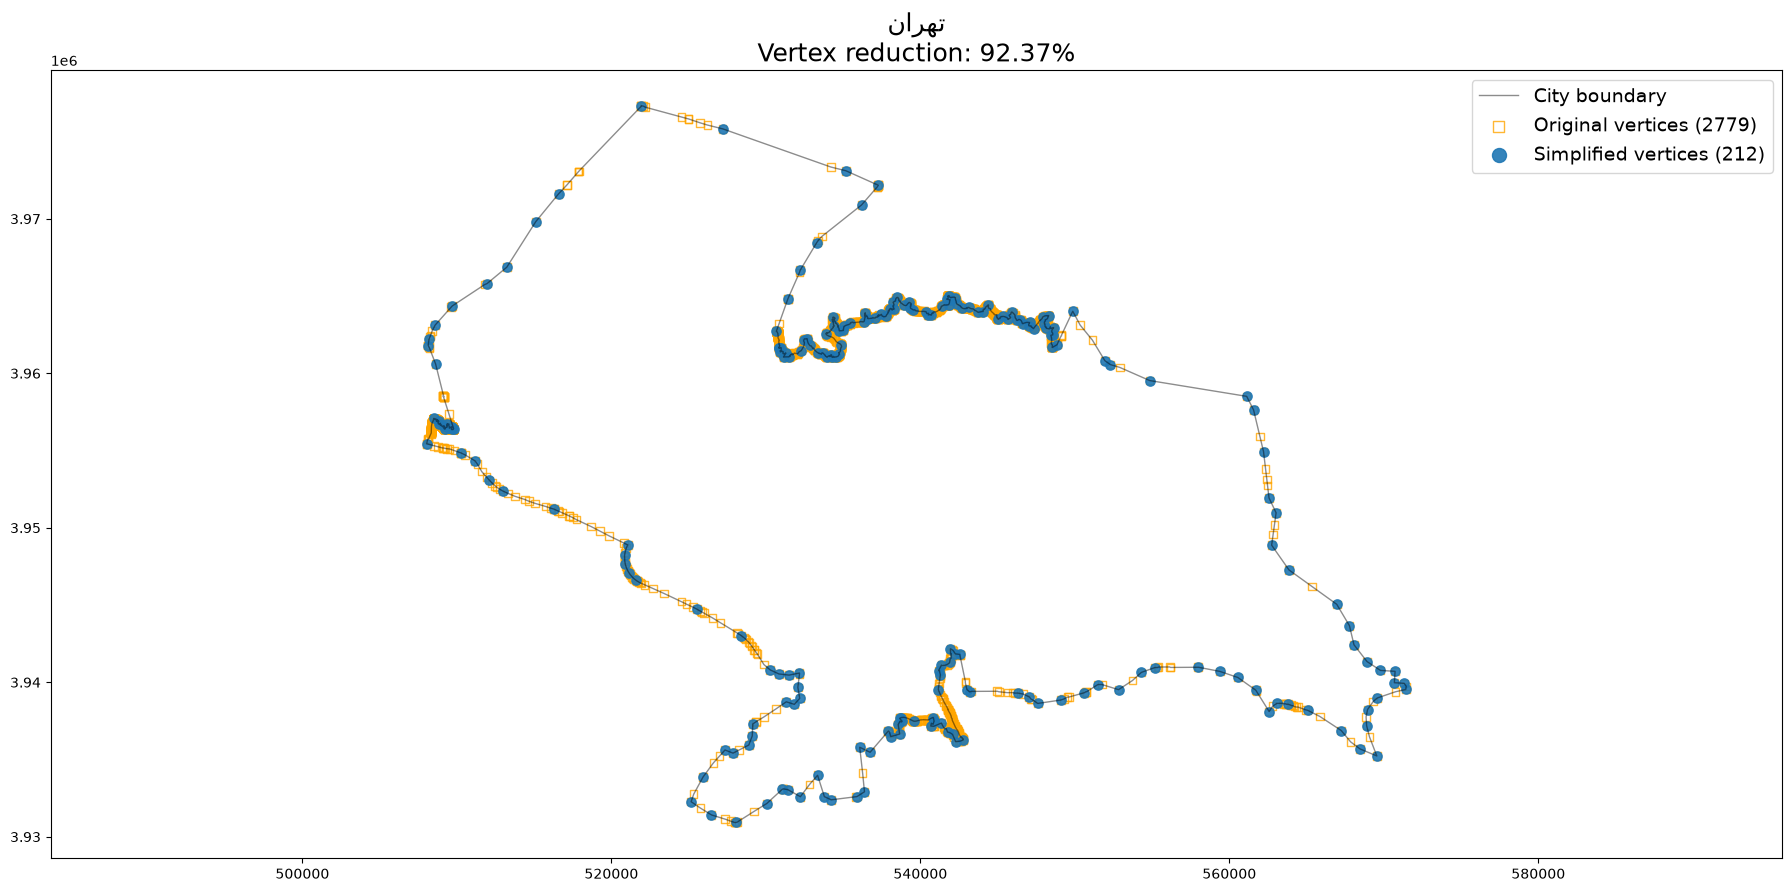

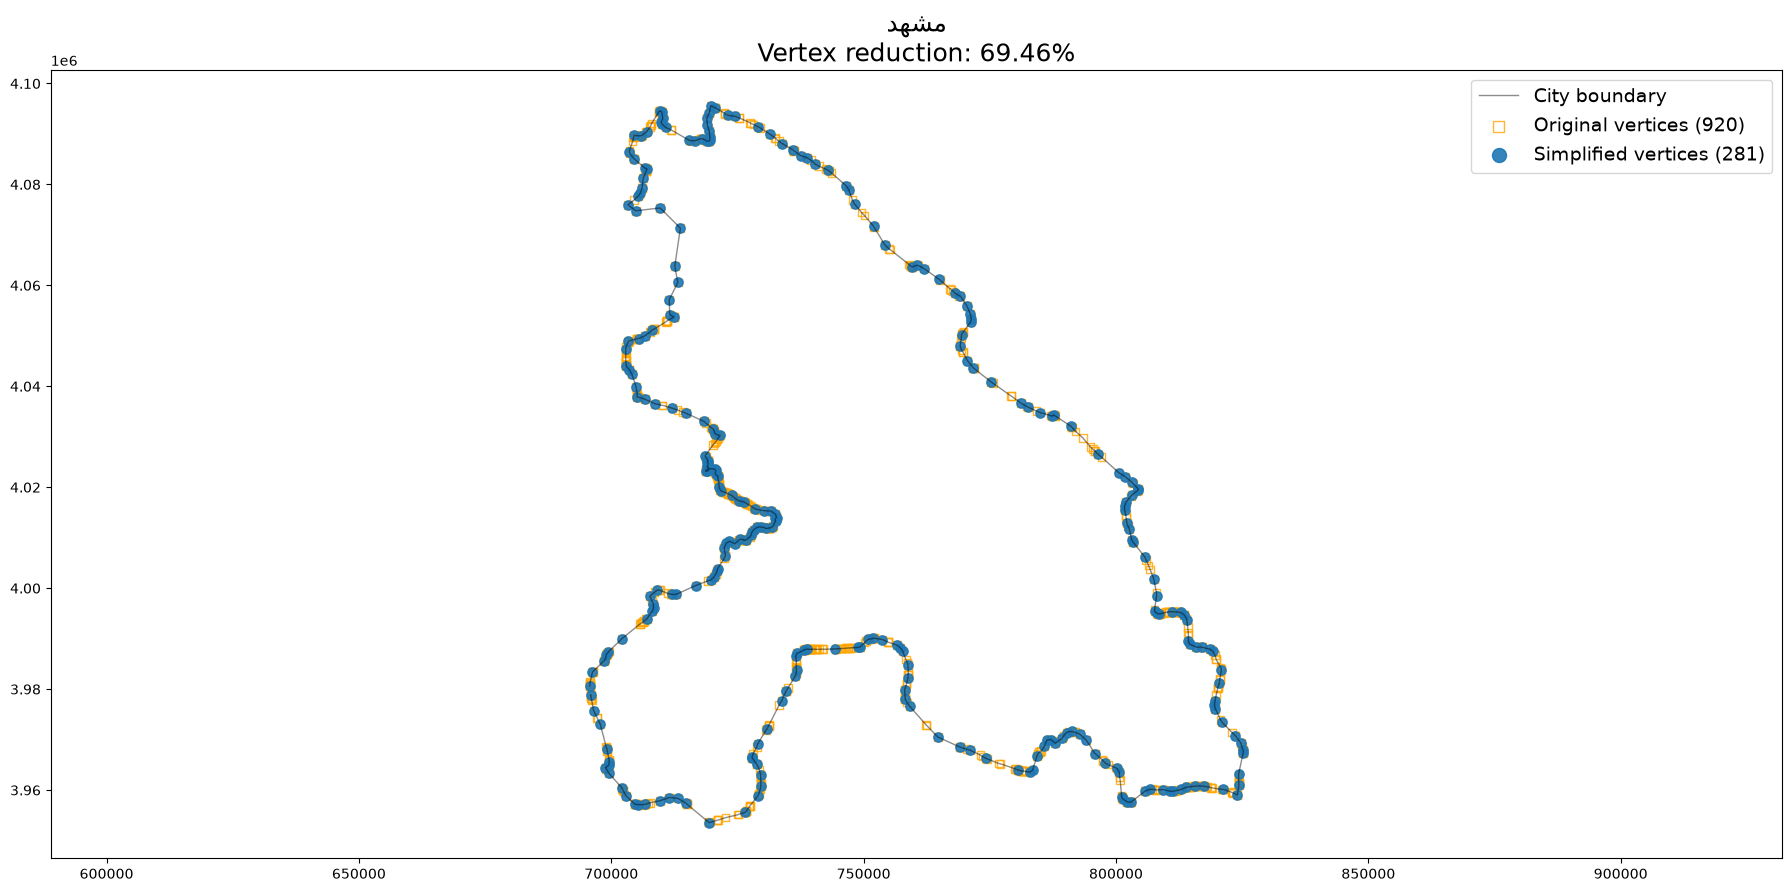

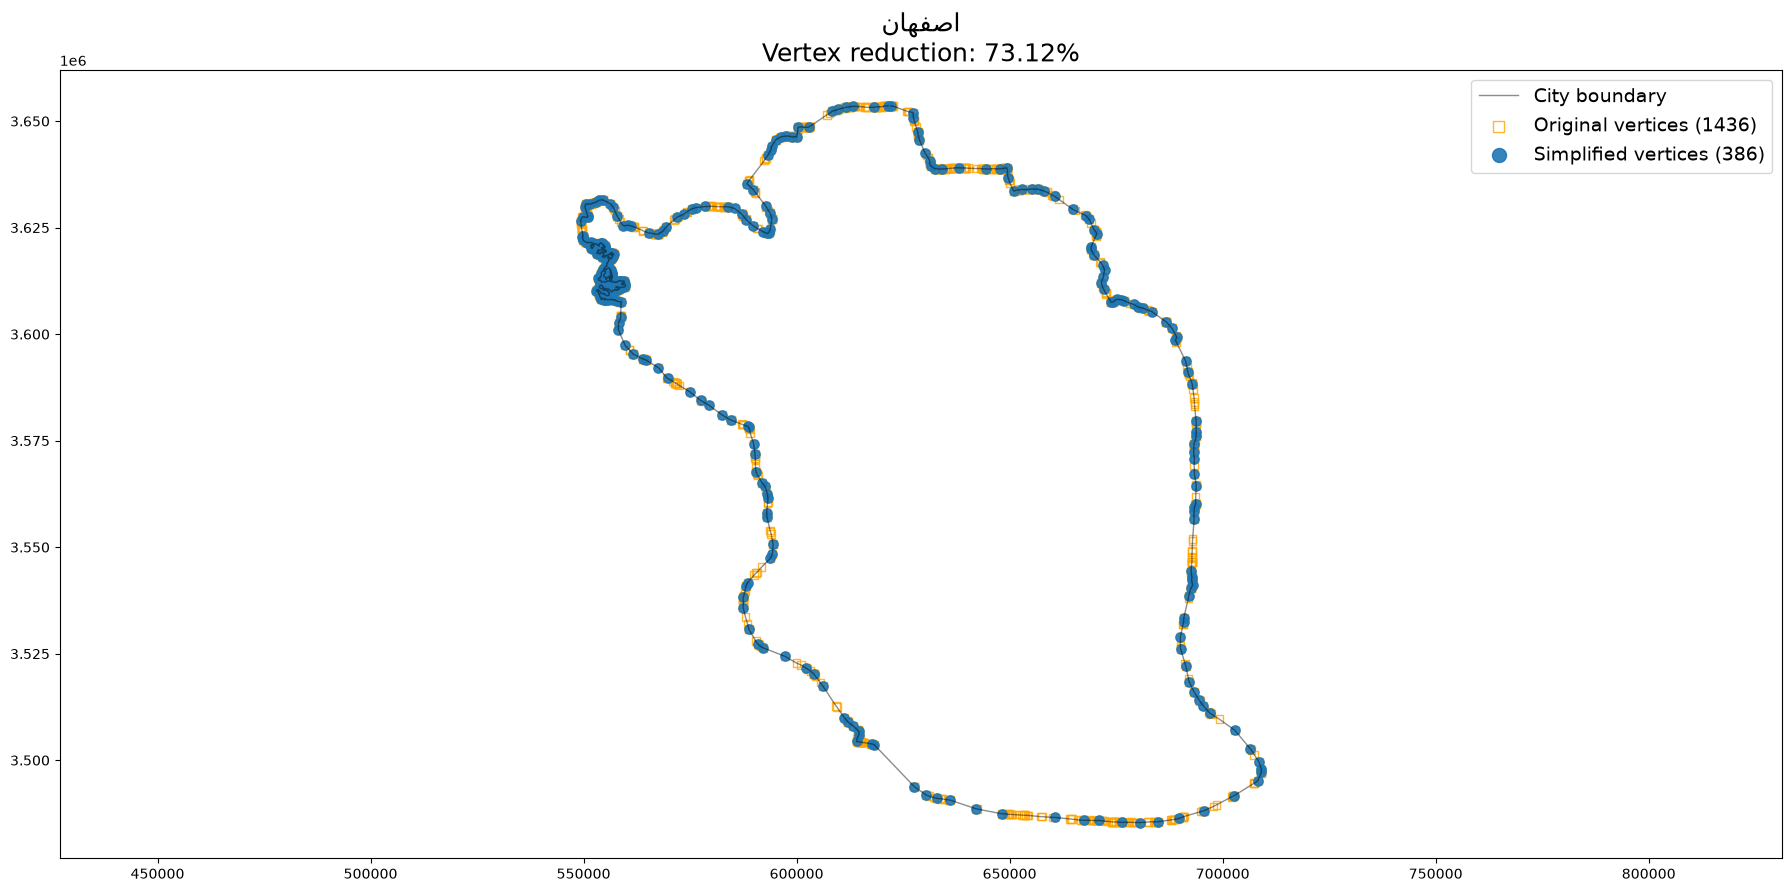

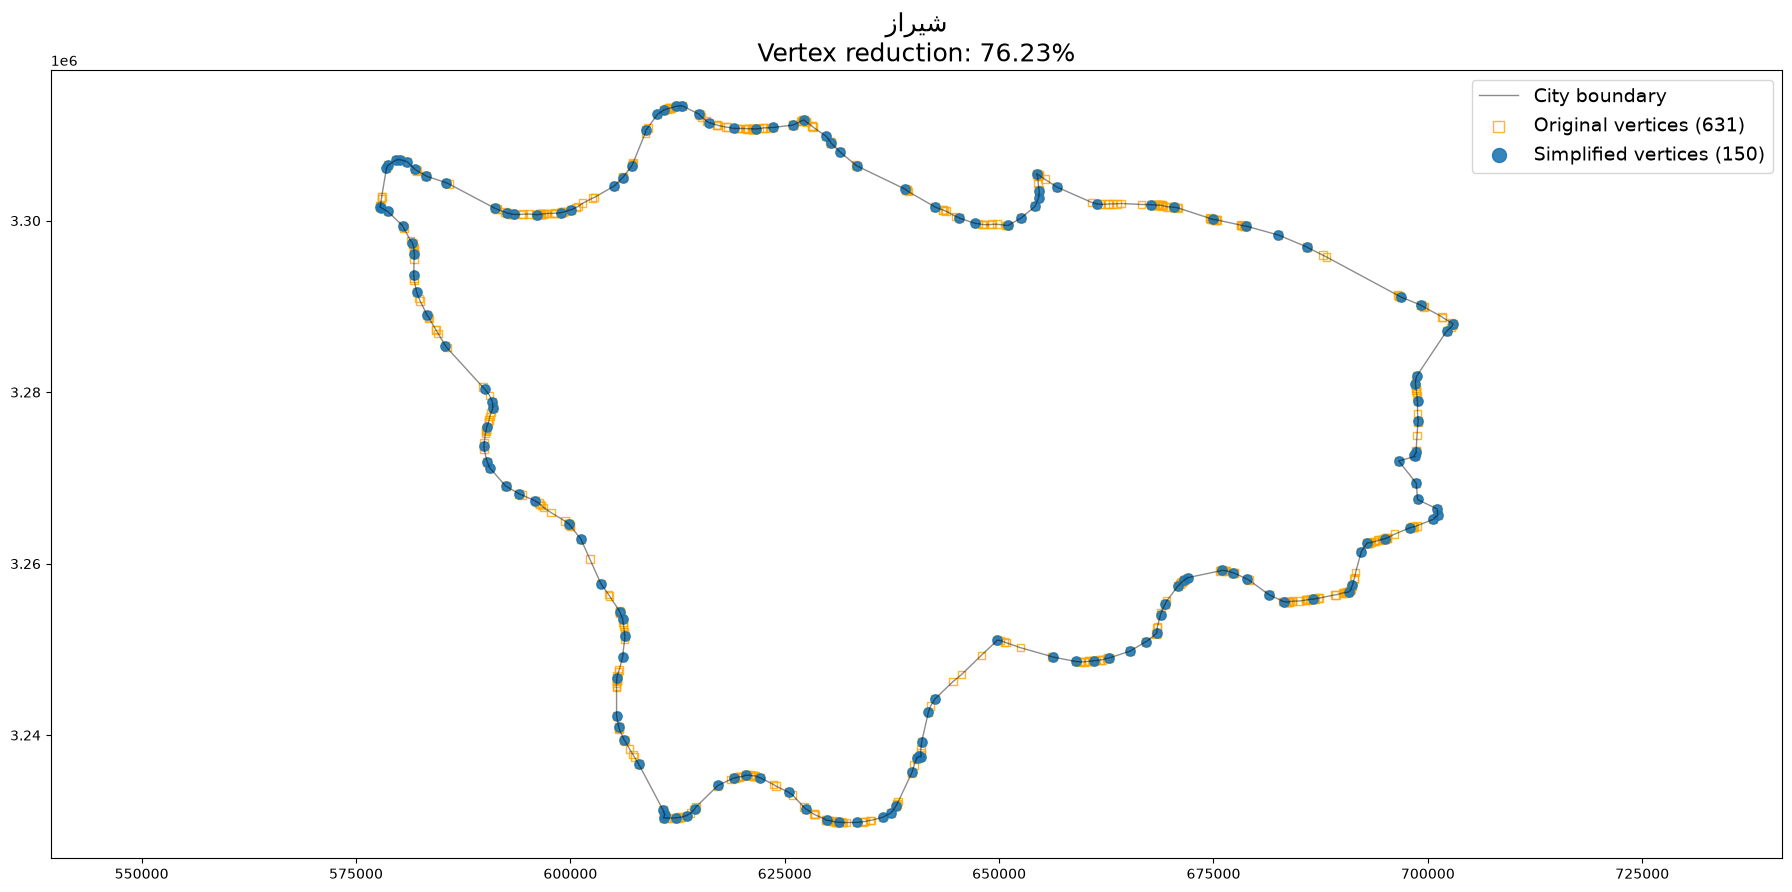

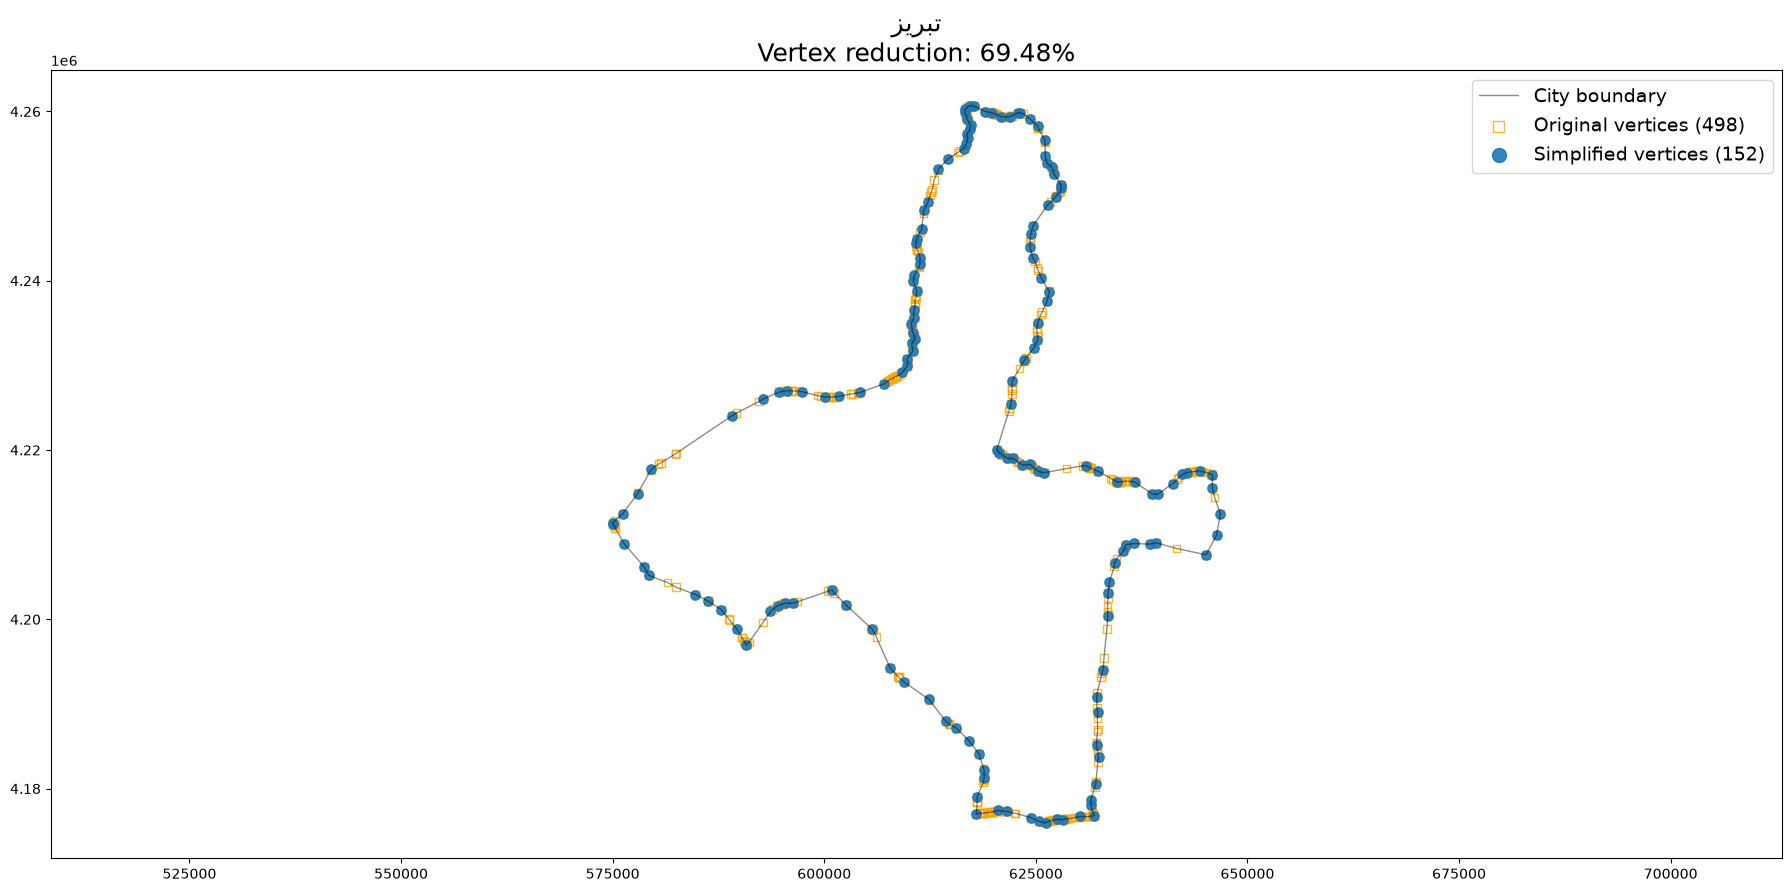

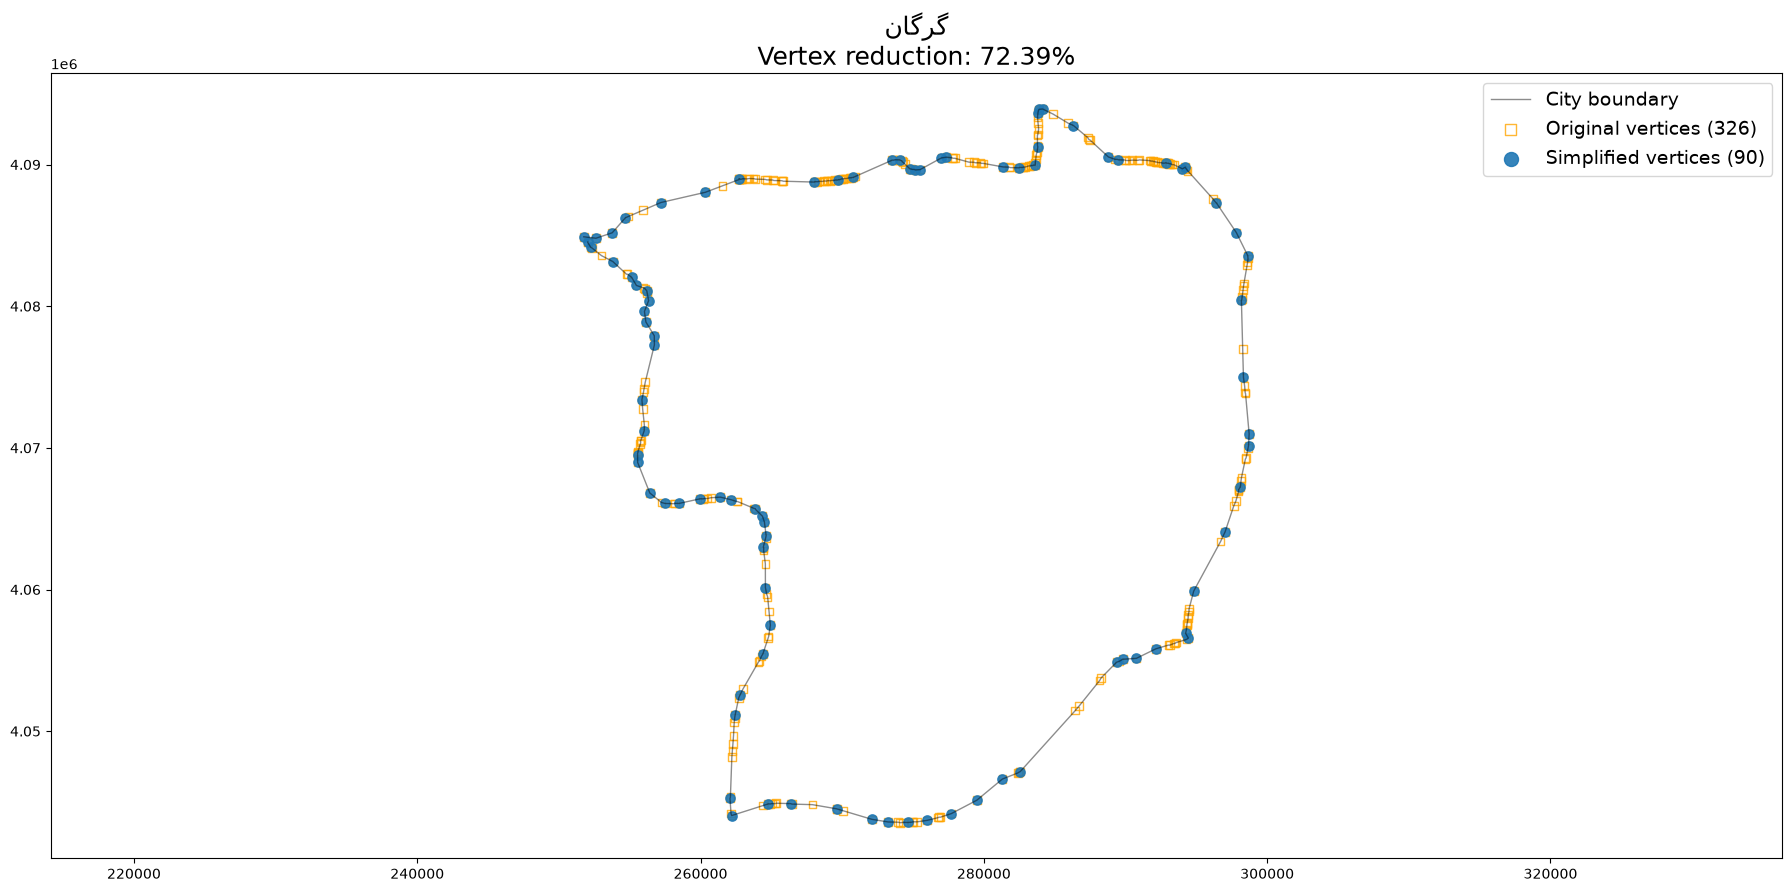

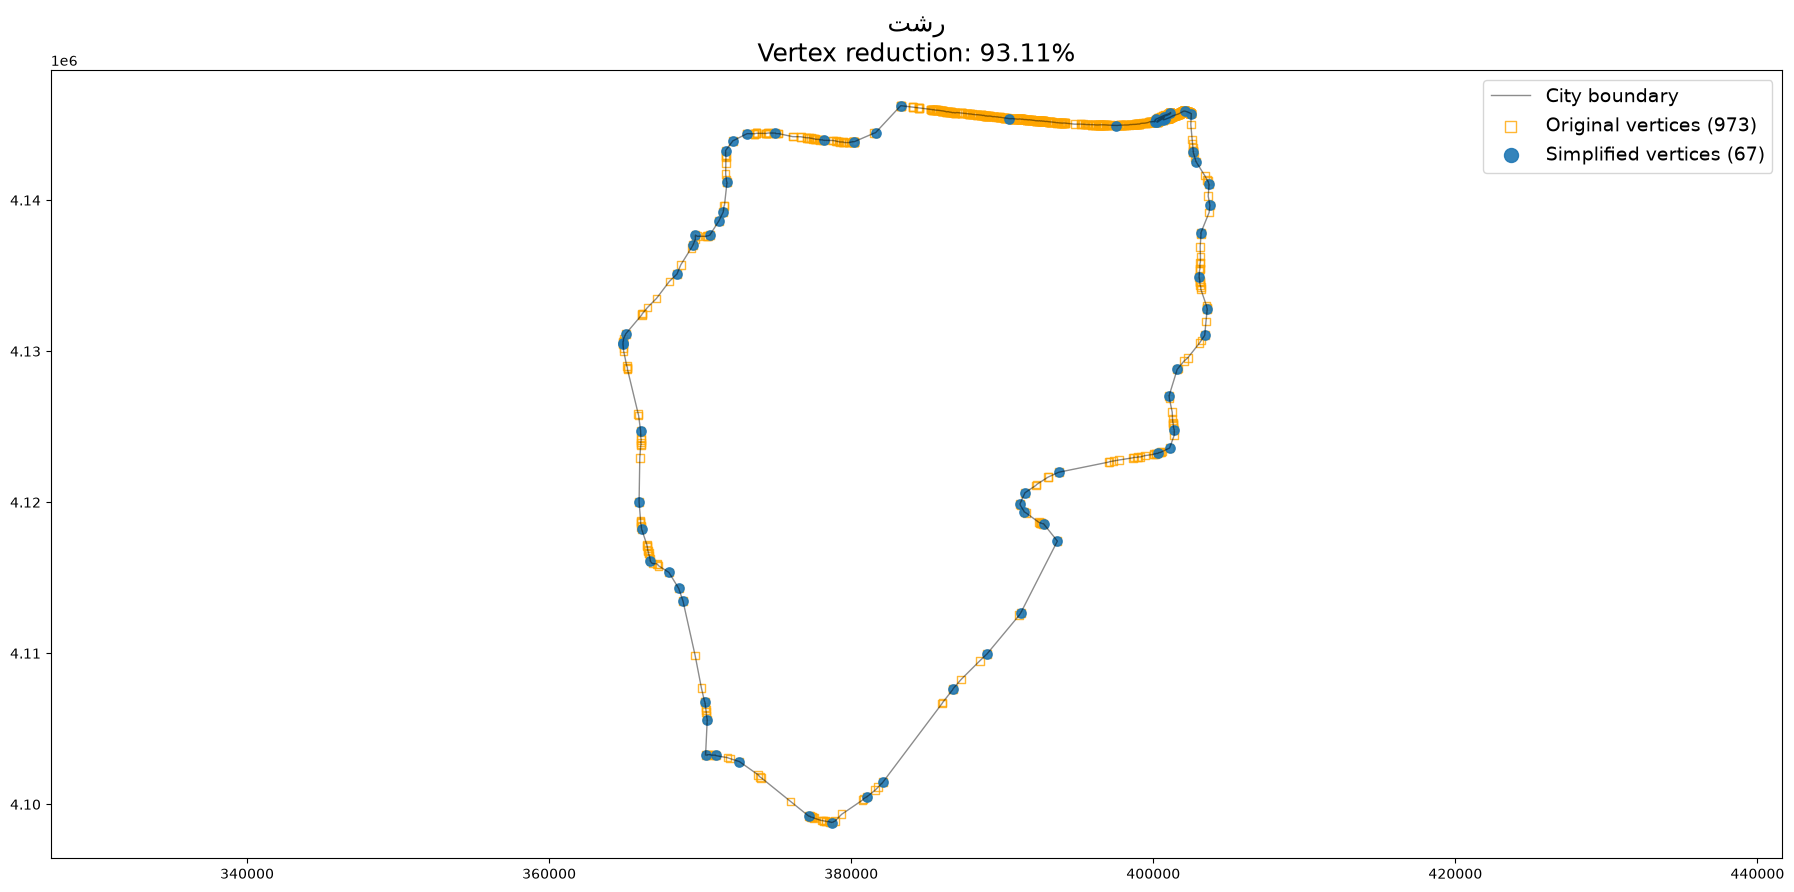

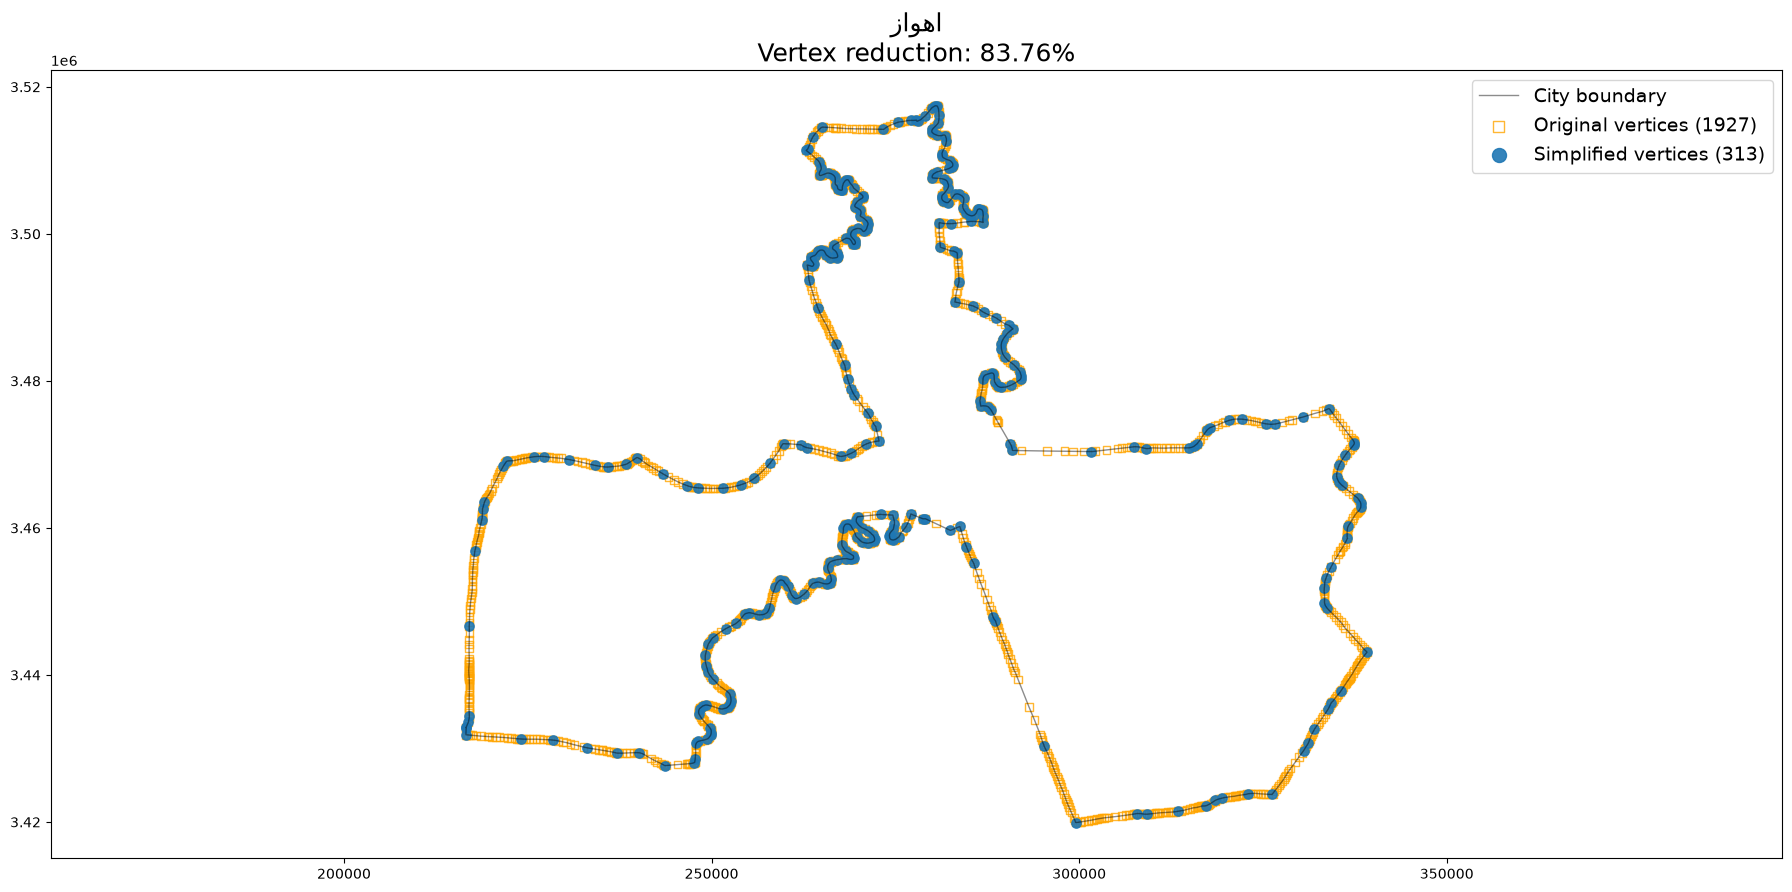

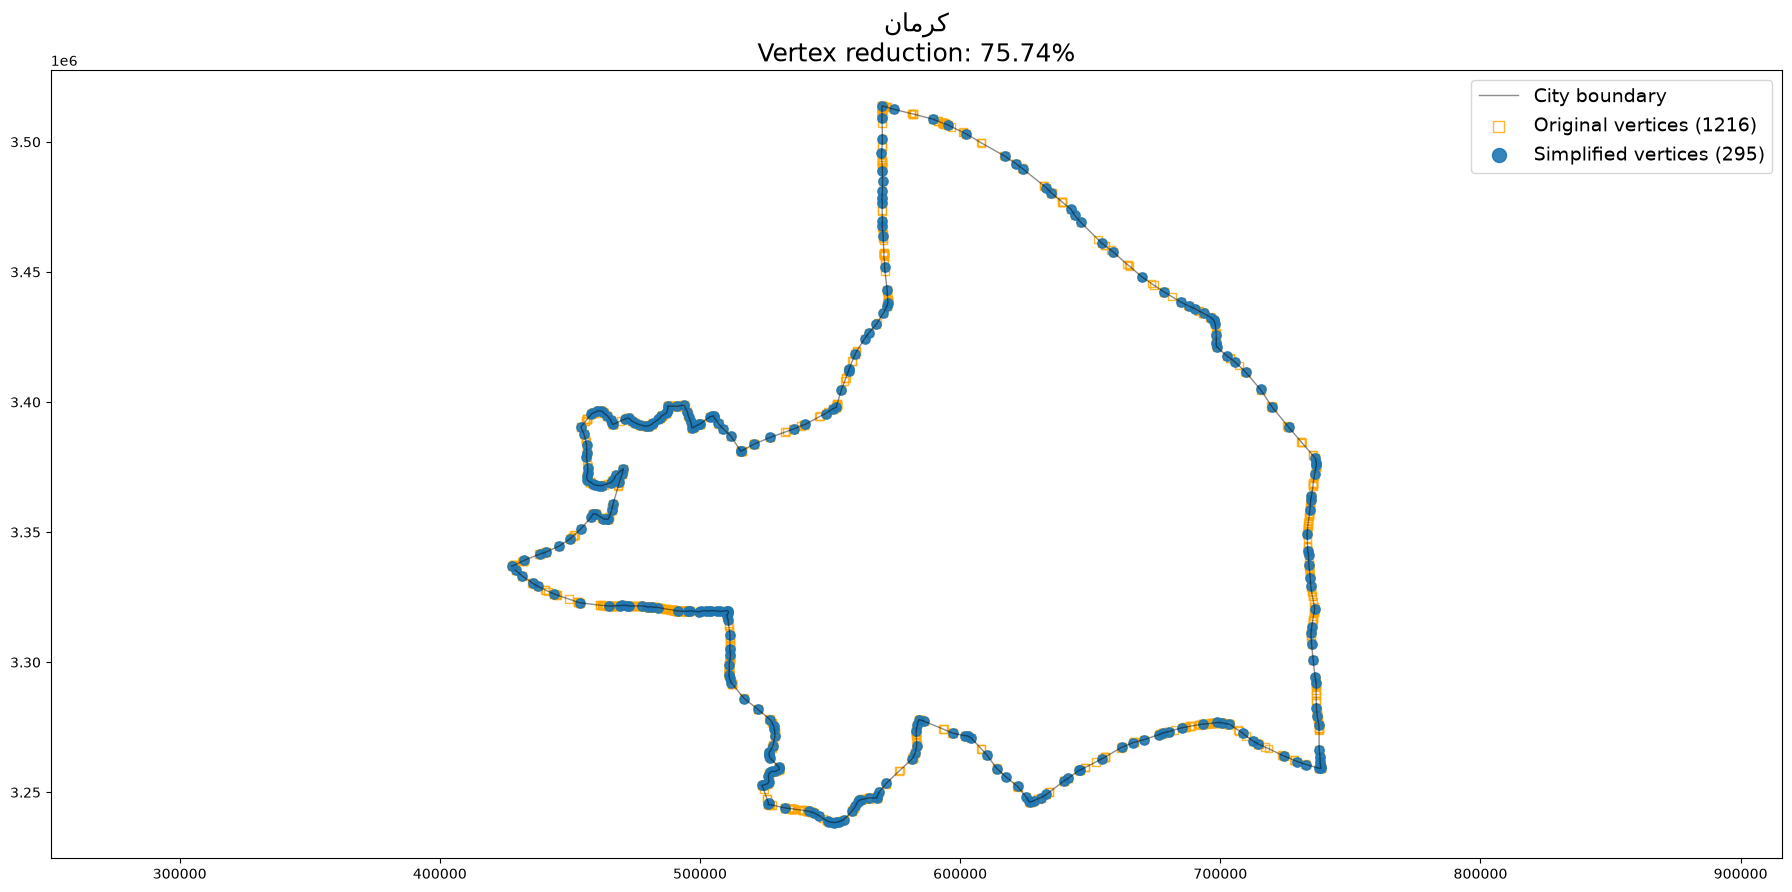

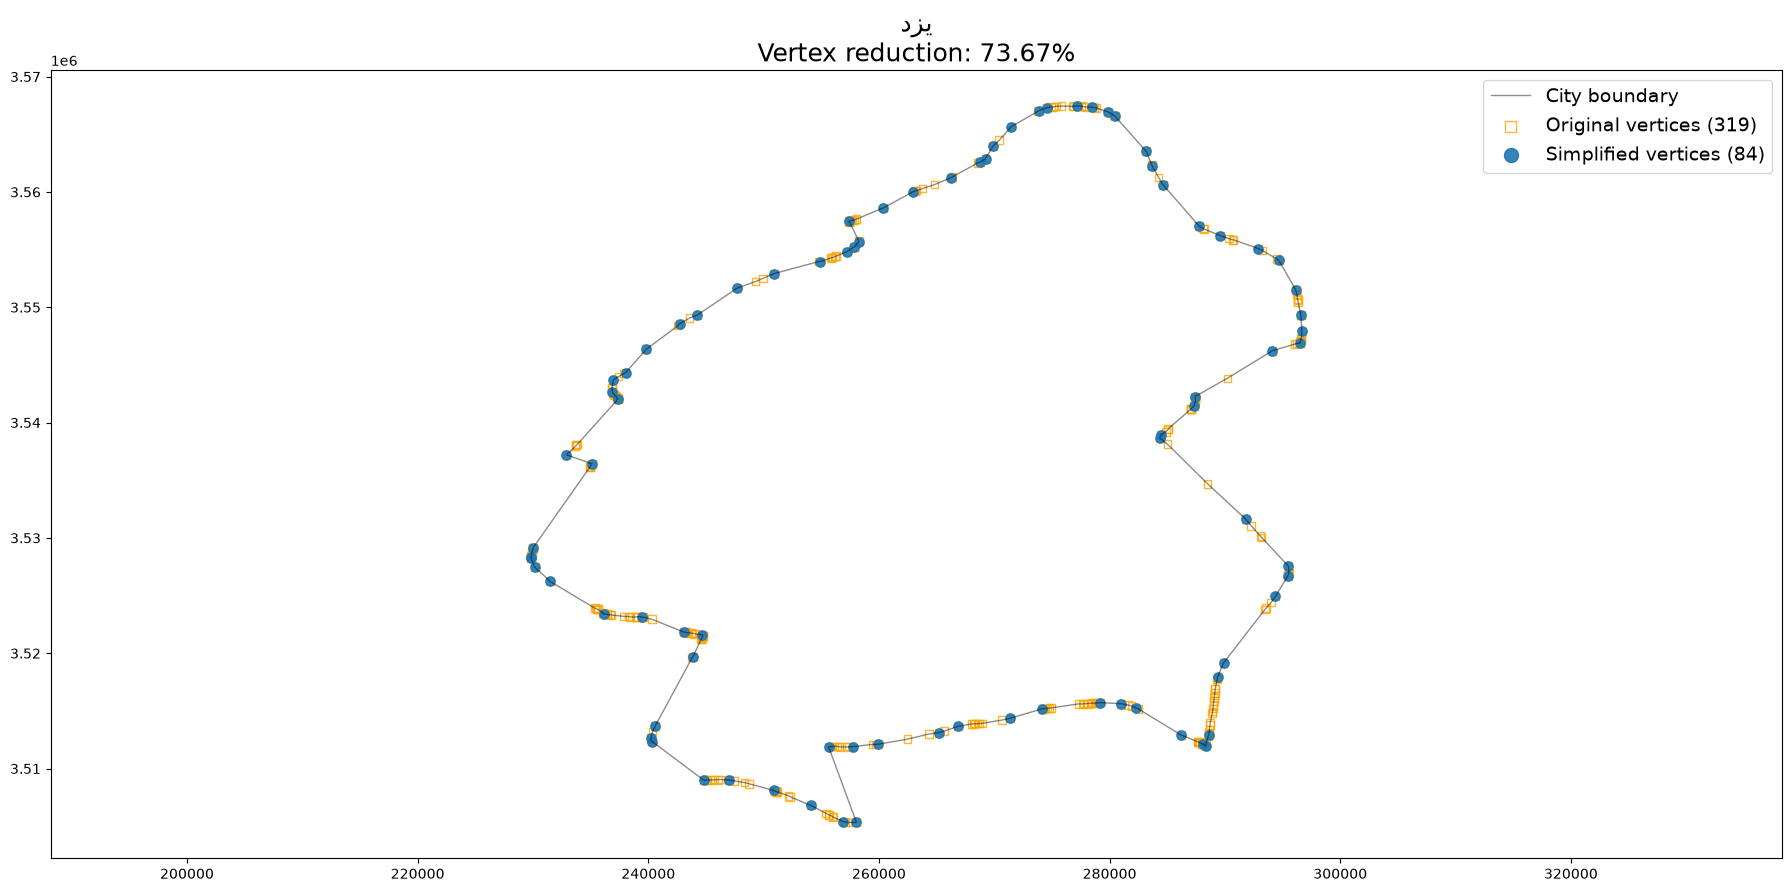

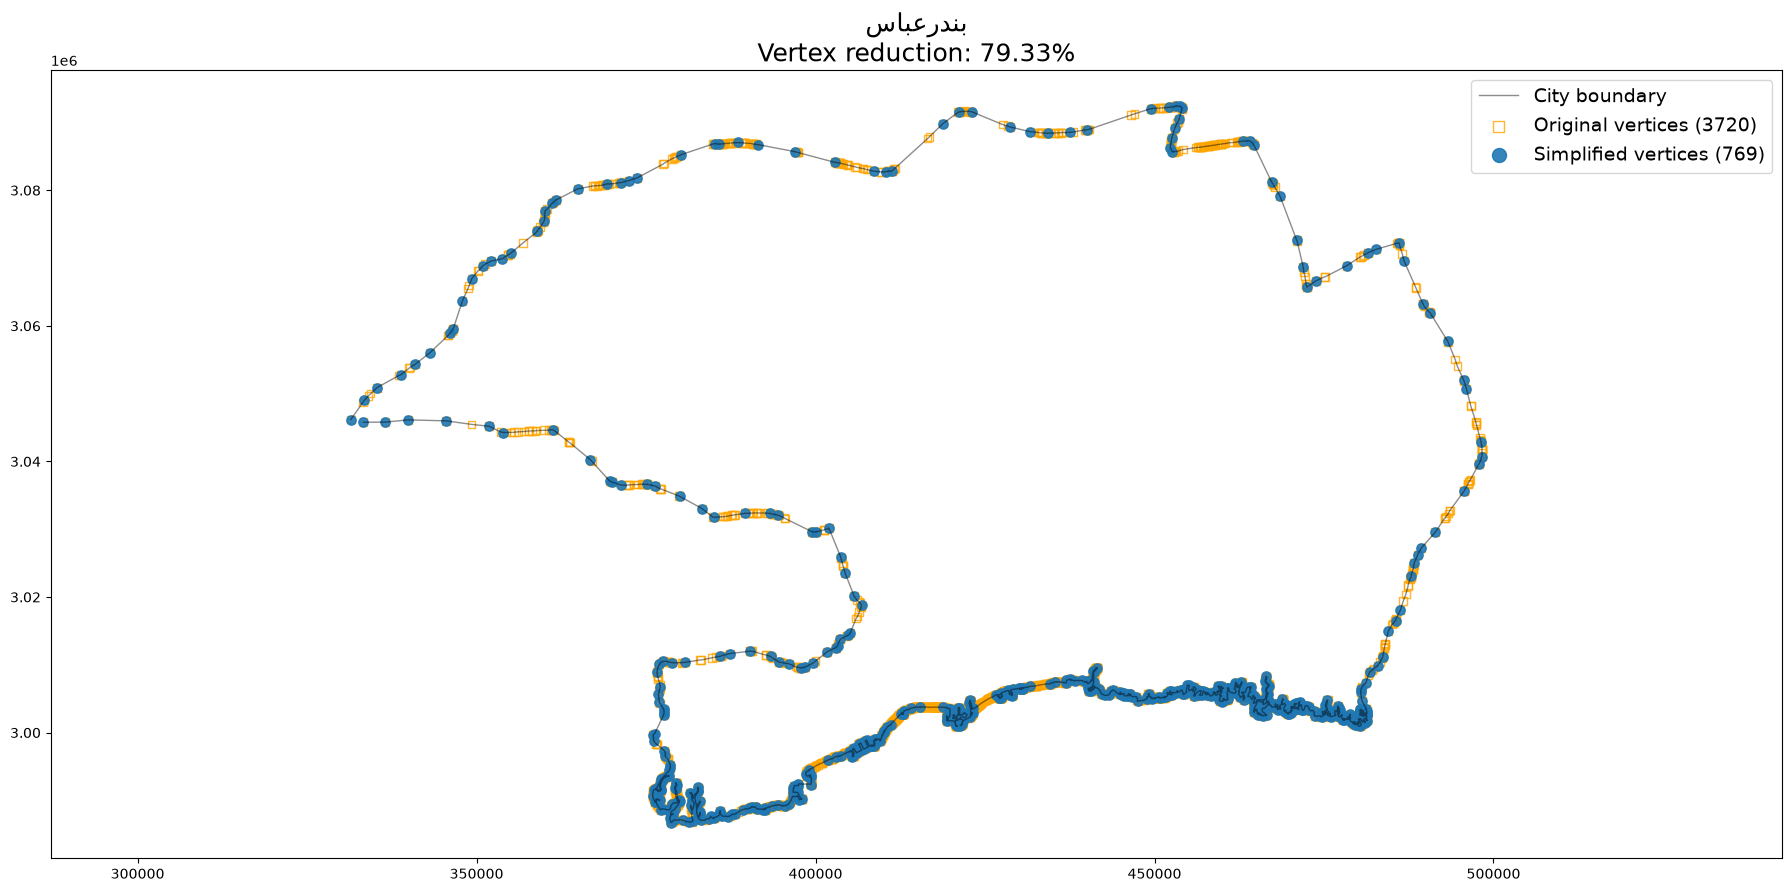

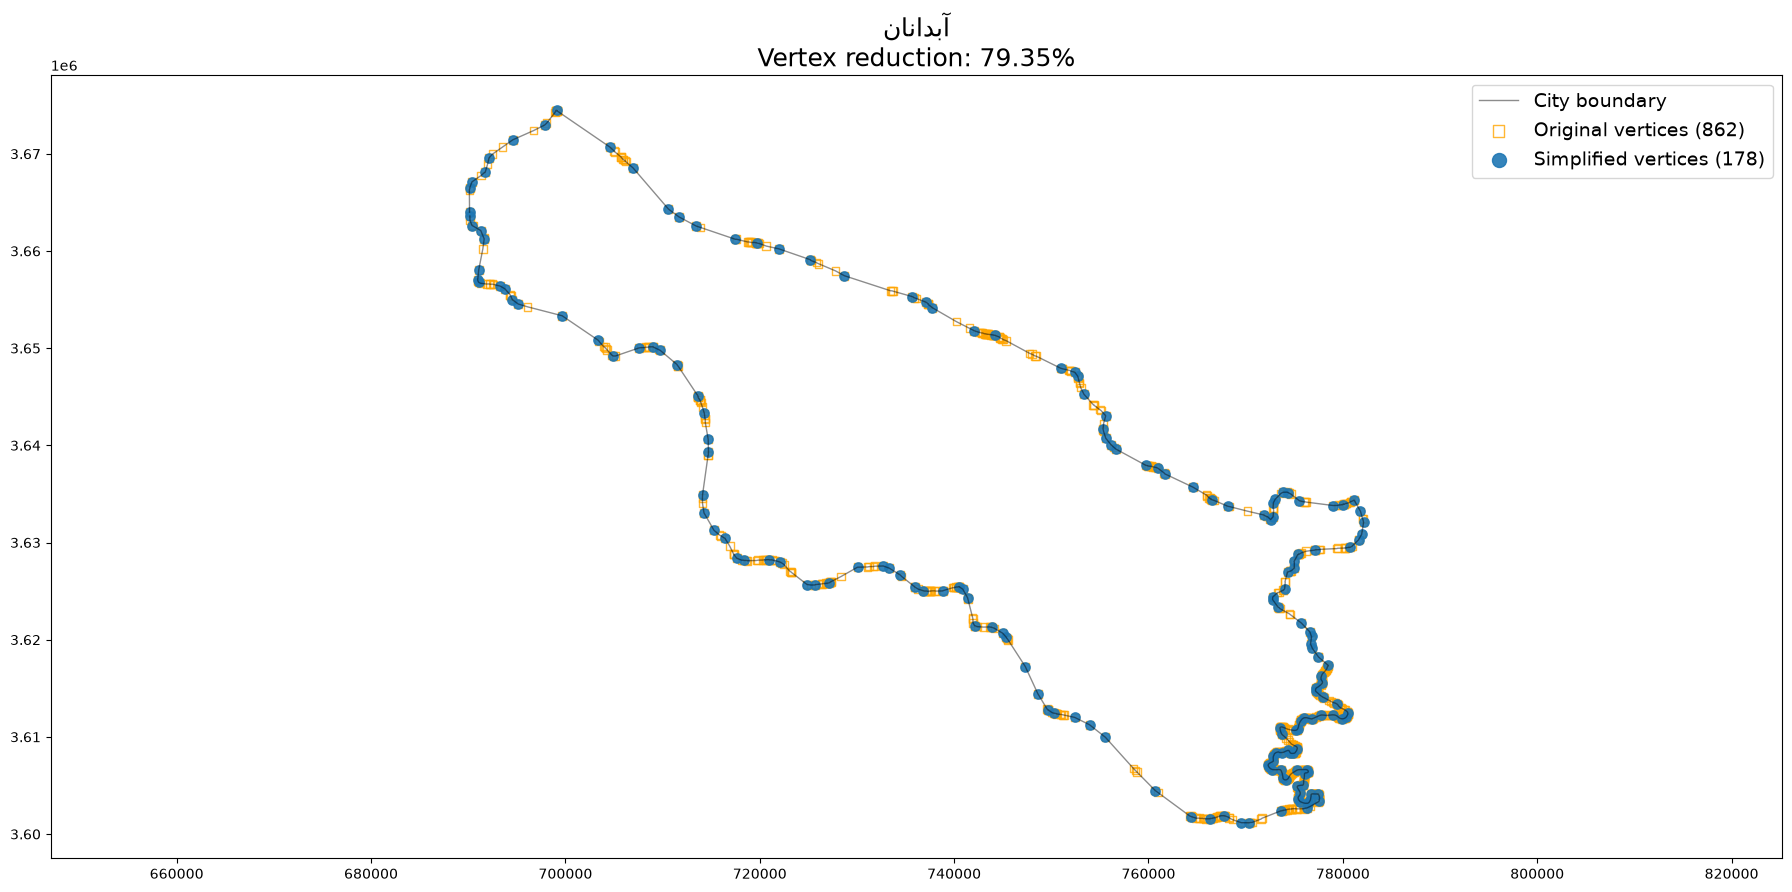

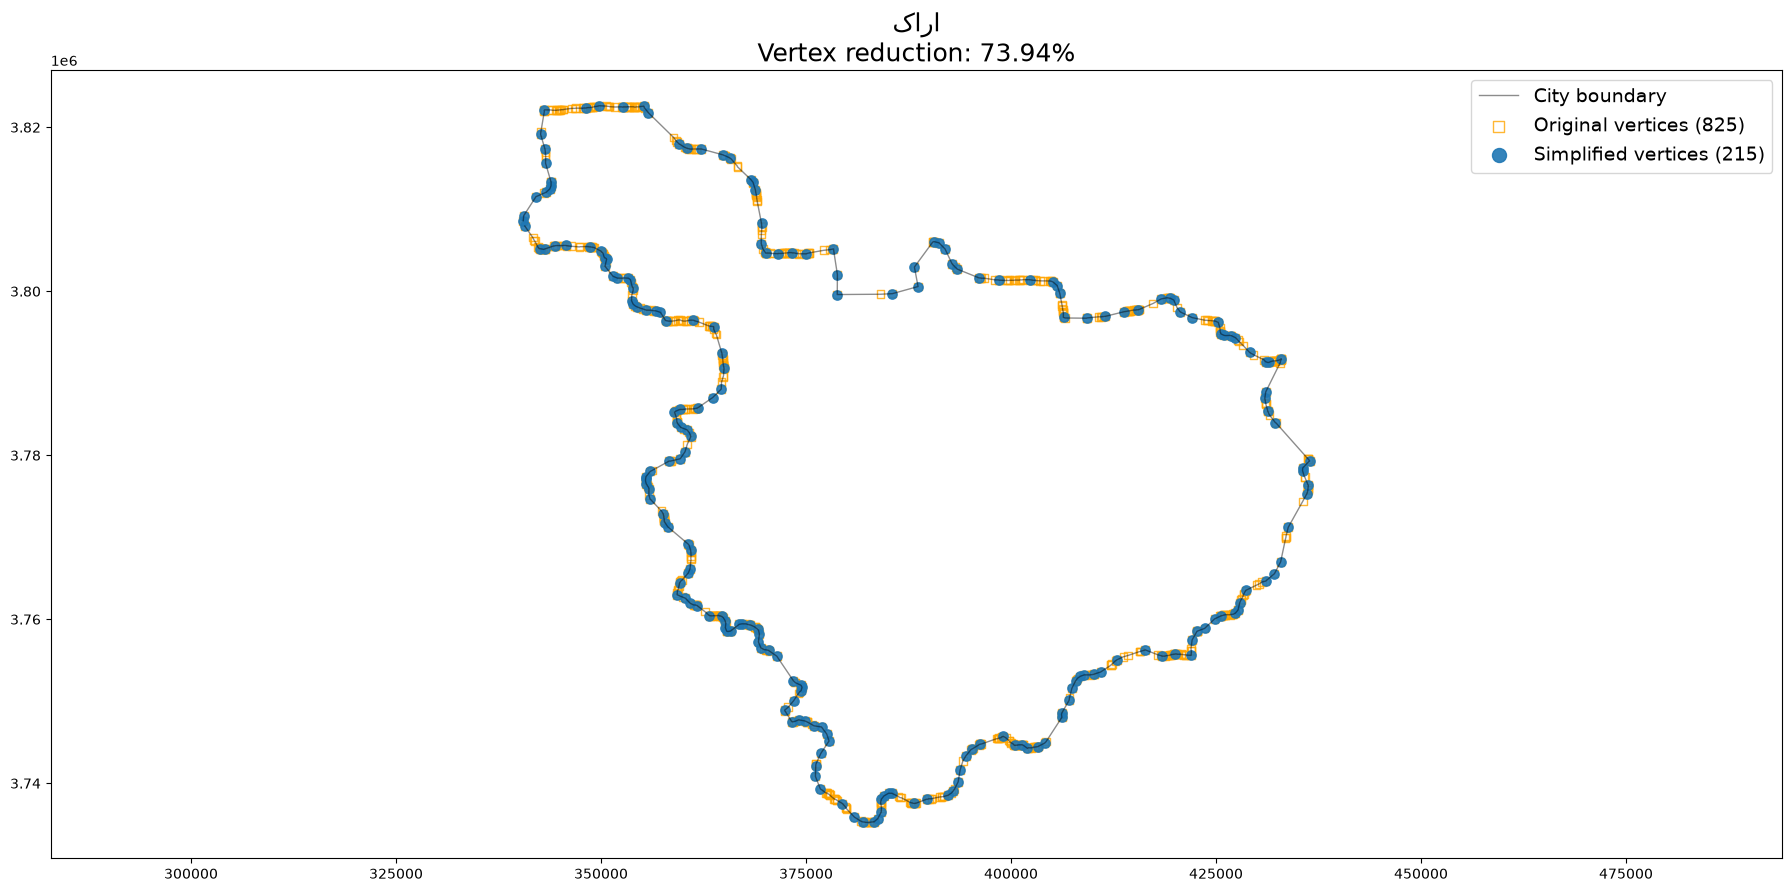

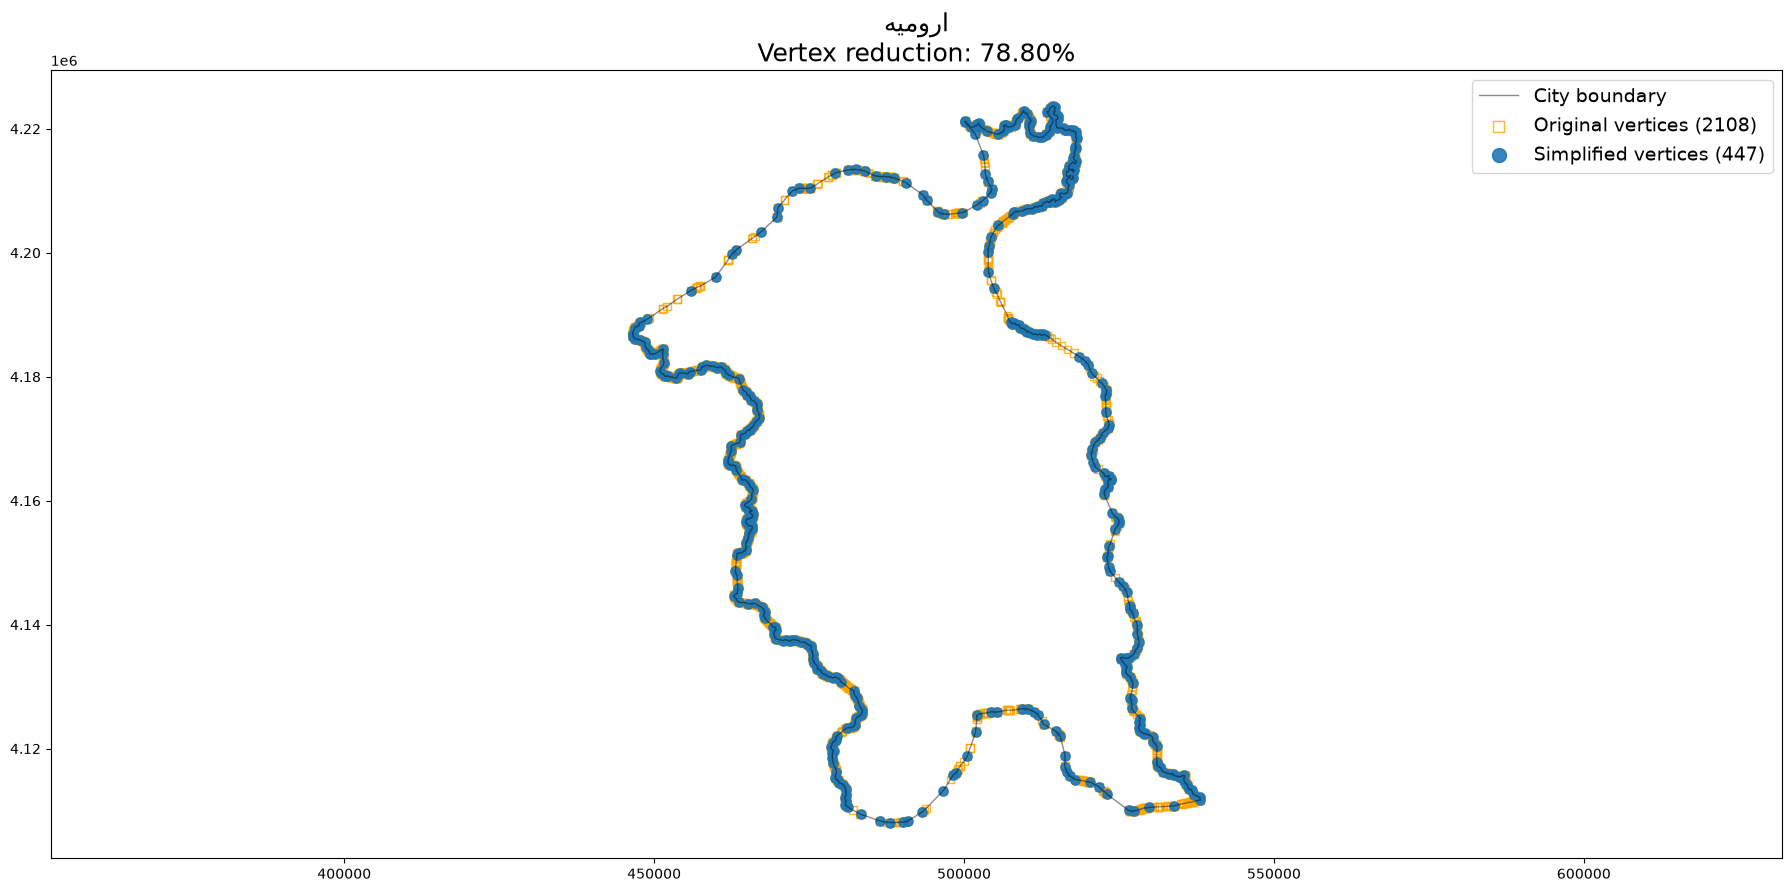

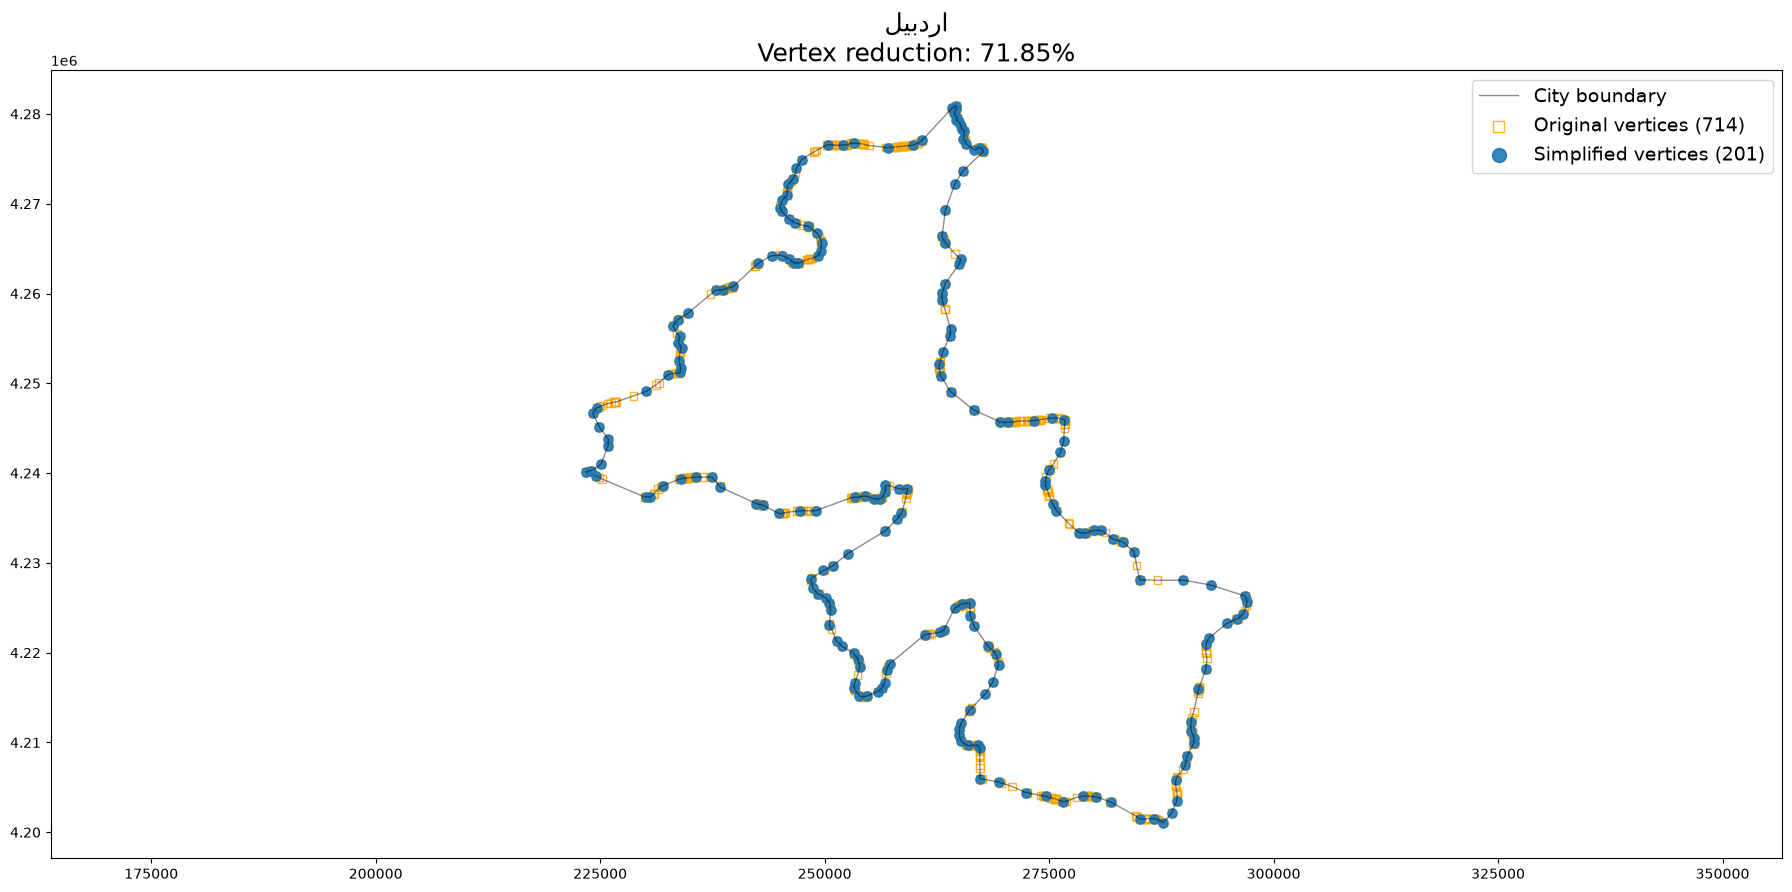

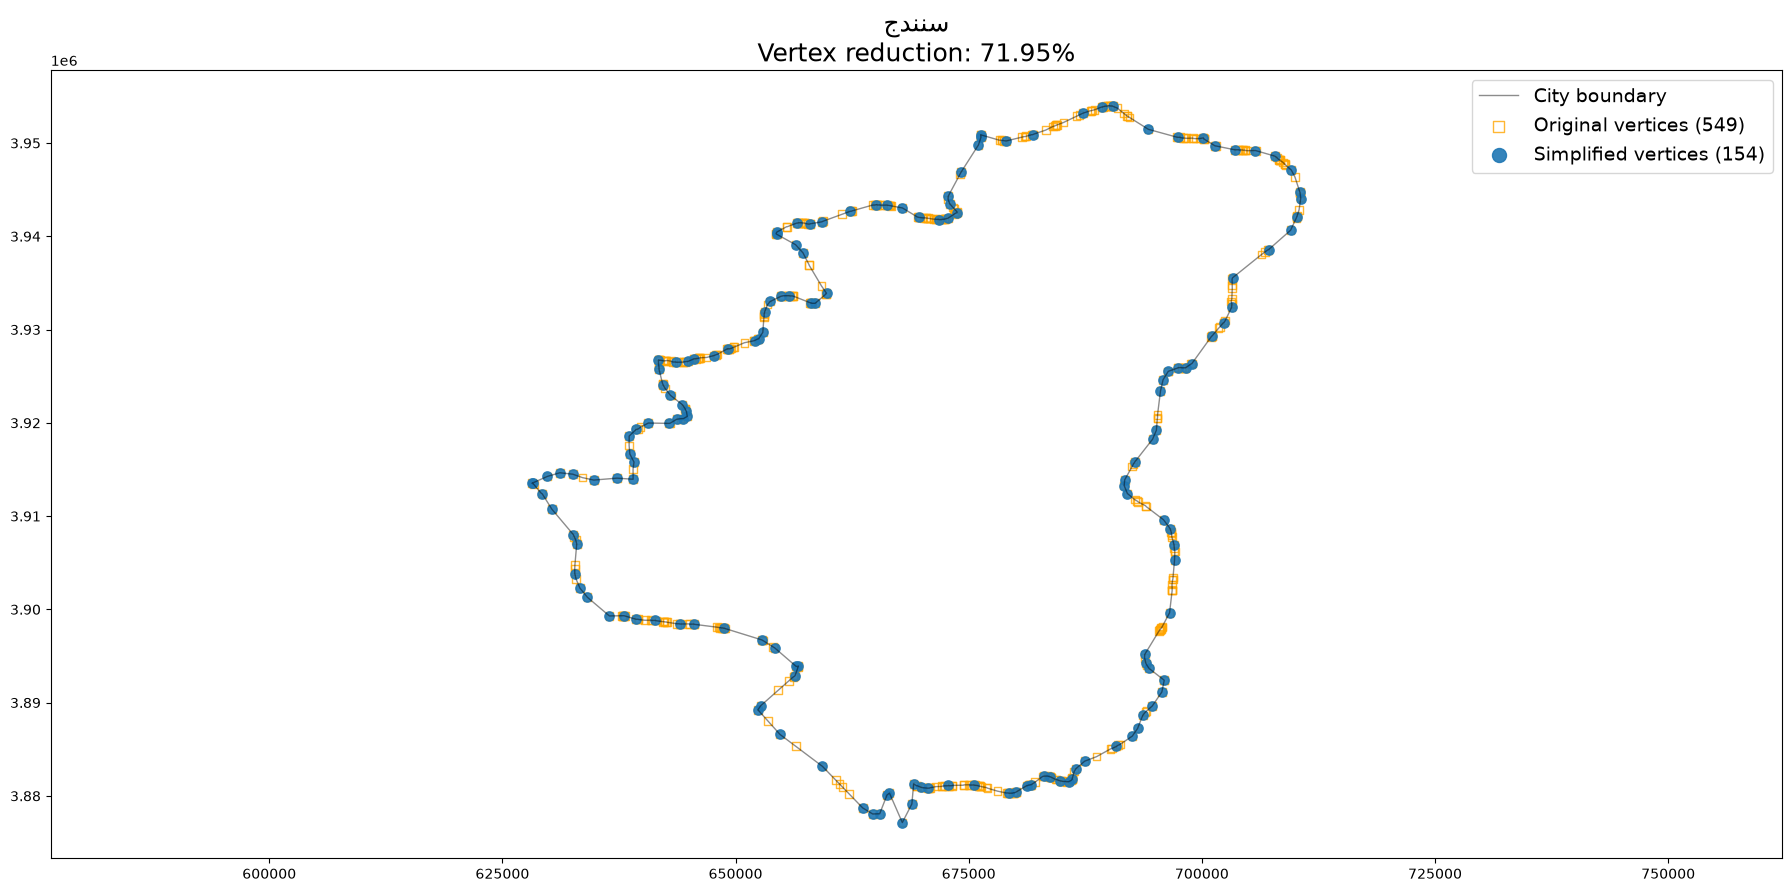

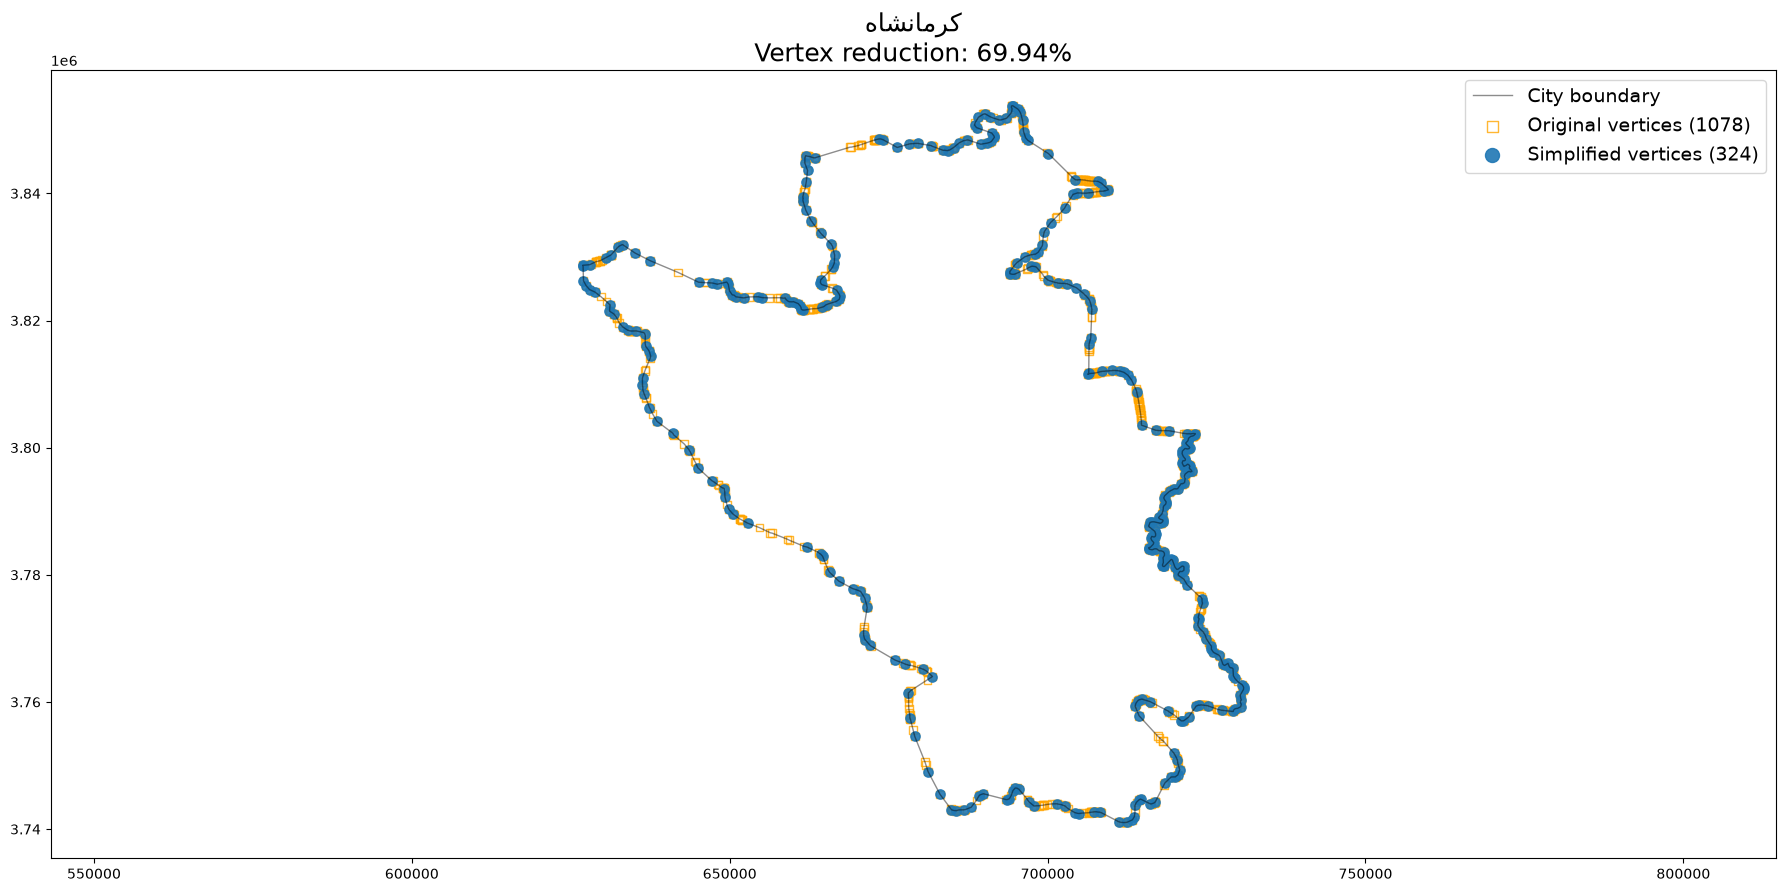

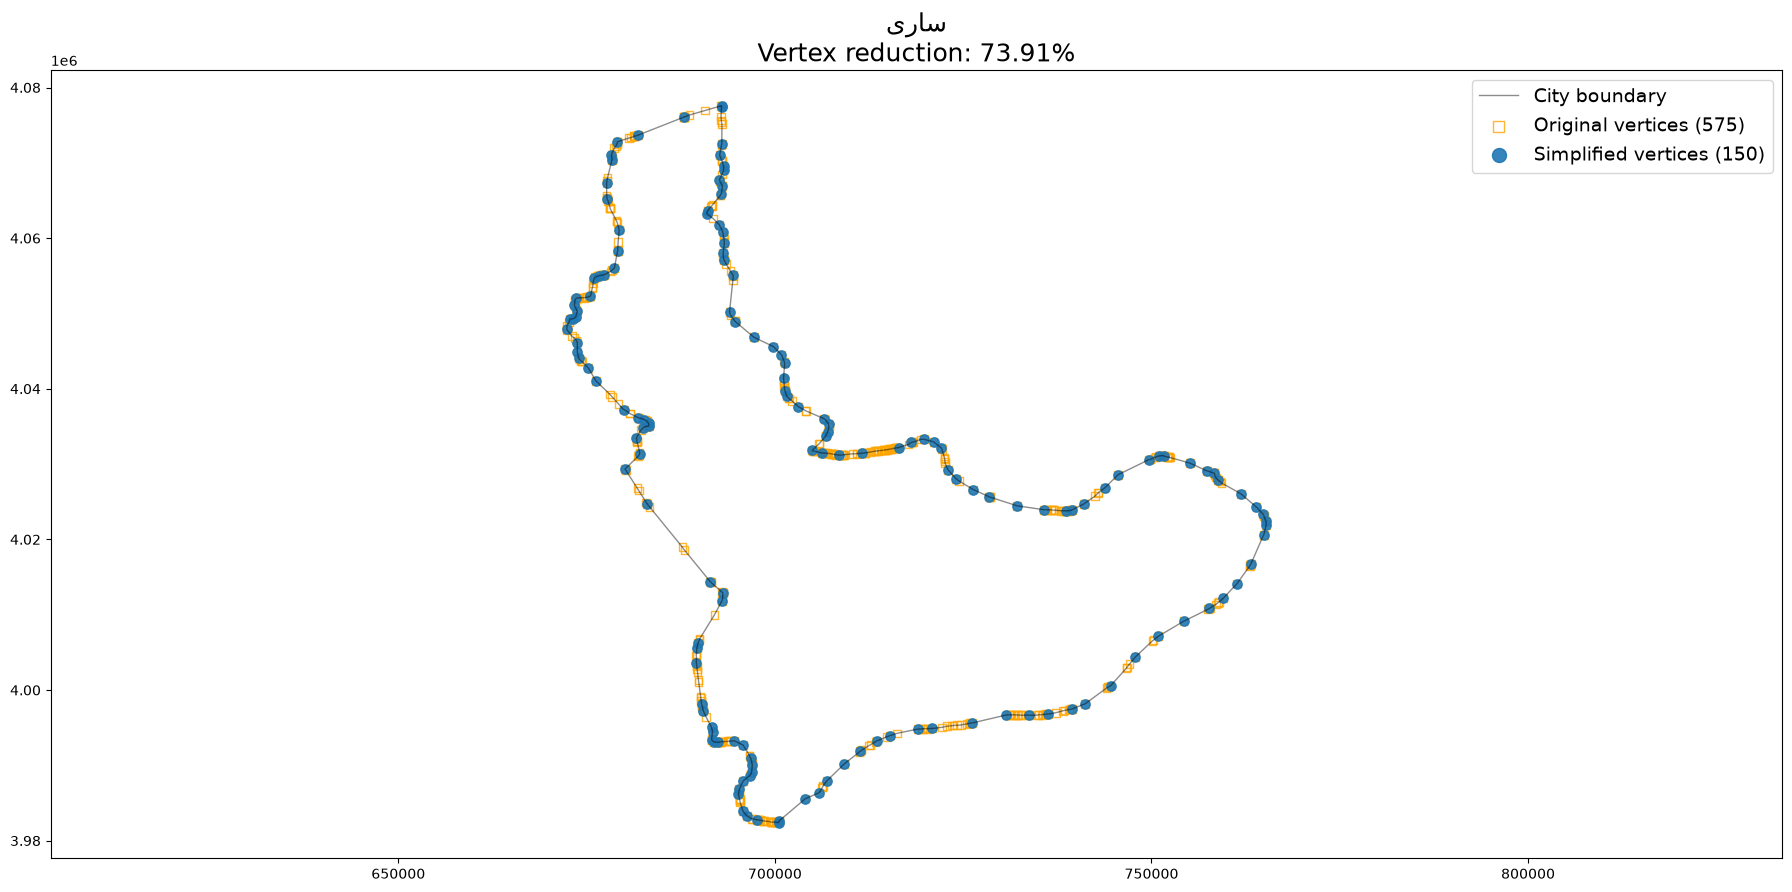

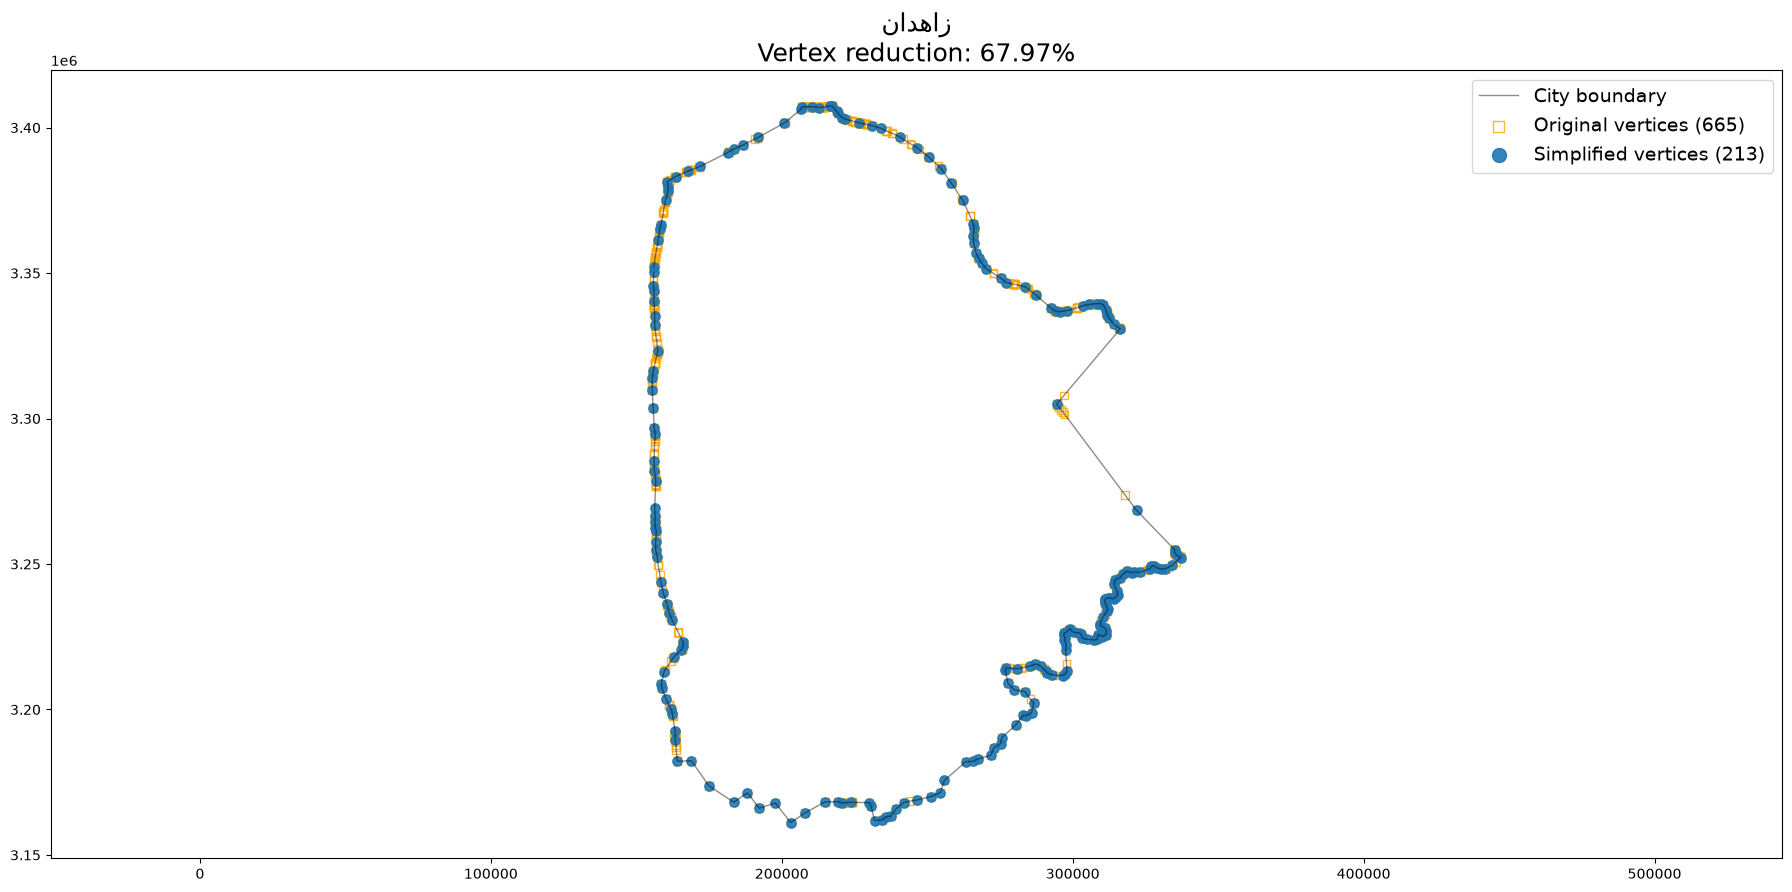

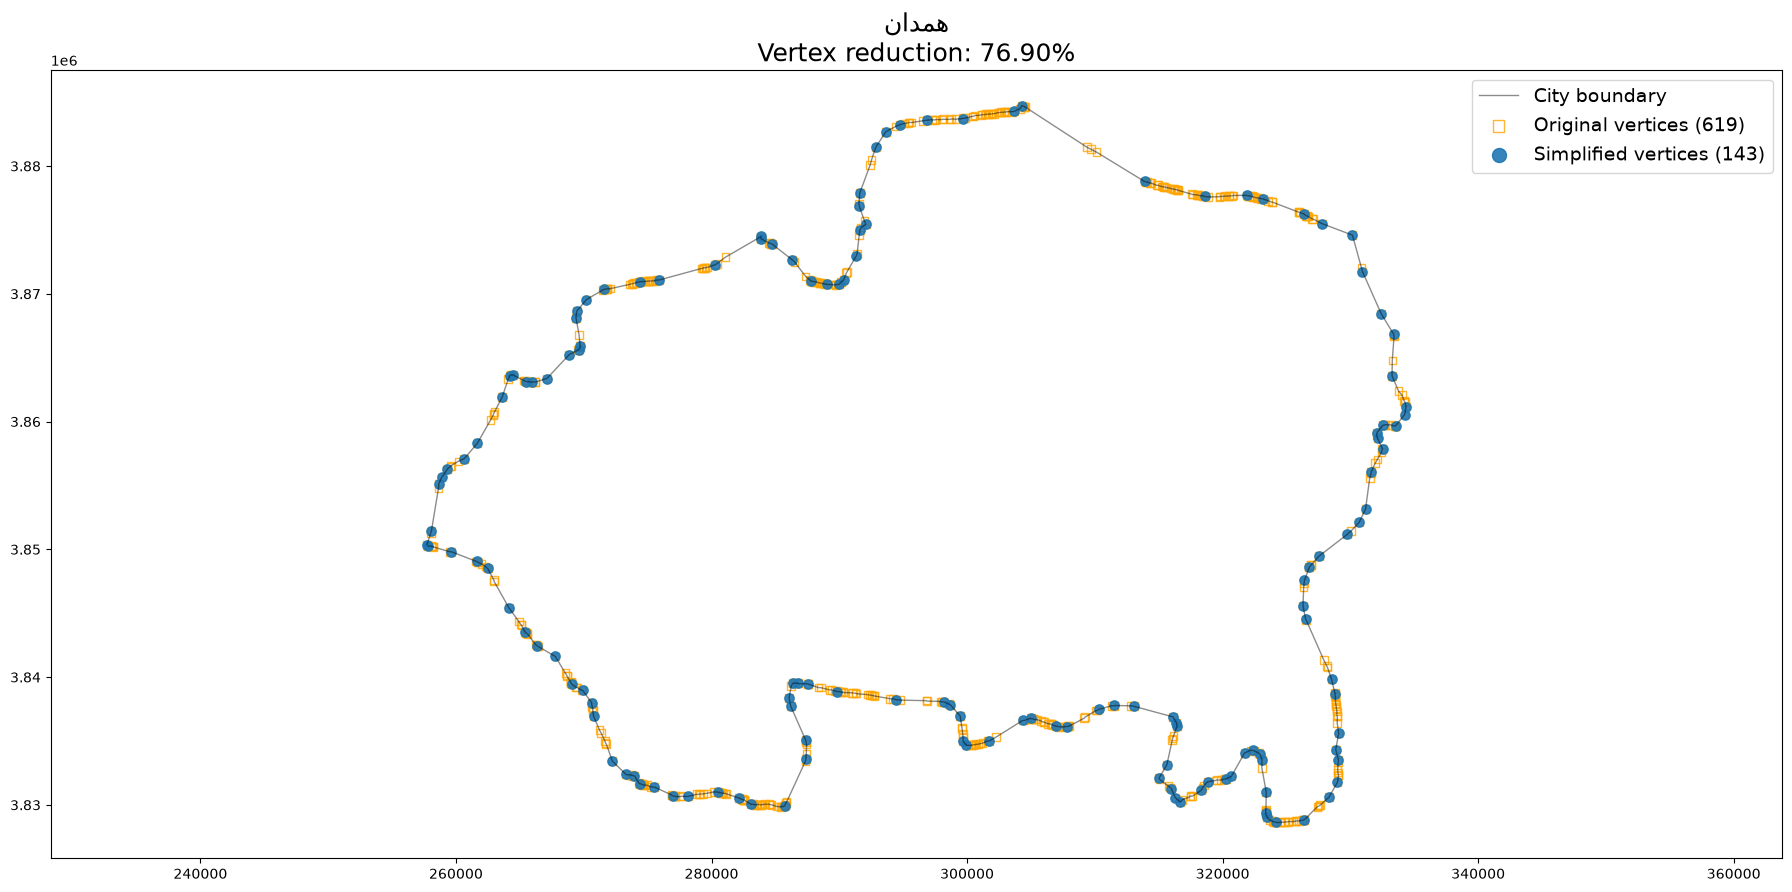

In [110]:
for city, data in sample_results.items():
    plot_polygon_simplification(data["original_meter"], data["simplified"], city)